🧹 Data Cleaning

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("netflix_titles.csv")


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Number of Rows and Columns

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.shape

(8807, 12)

Data Type Information

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Visualization of Missing Values

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["director"] = df["director"].fillna("Unknown")

In [11]:
df["cast"] = df["cast"].fillna("Not Available")

In [12]:
df["country"] = df["country"].fillna("Unknown")

In [13]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

Handling Missing Values

In [14]:
df = df.dropna(subset=["date_added"])

In [15]:
df = df.dropna(subset=["duration"])

In [16]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

📊 Exploratory Data Analysis (EDA)

🥧 Analysing: Distribution of Movies and TV Shows

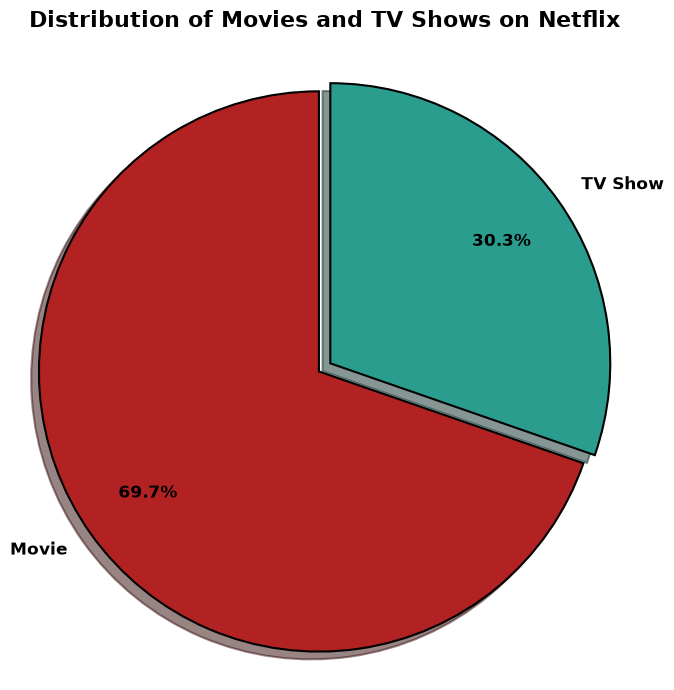

In [17]:
plt.figure(figsize=(7,7))
content = df.groupby("type").size()
colors = ["firebrick", "#2A9D8F"]   # Red and Teal
explode = (0.05, 0)

plt.pie(content,labels=content.index,autopct="%1.1f%%",startangle=90,colors=colors,explode=explode,shadow=True,pctdistance=0.75,
    wedgeprops={"edgecolor": "black","linewidth": 1.5},
    textprops={"fontsize": 12,"fontweight": "bold"})

plt.title("Distribution of Movies and TV Shows on Netflix", fontsize=16,fontweight="bold",pad=20)
plt.axis("equal")

plt.tight_layout()
plt.show()

ANALYSIS 2:

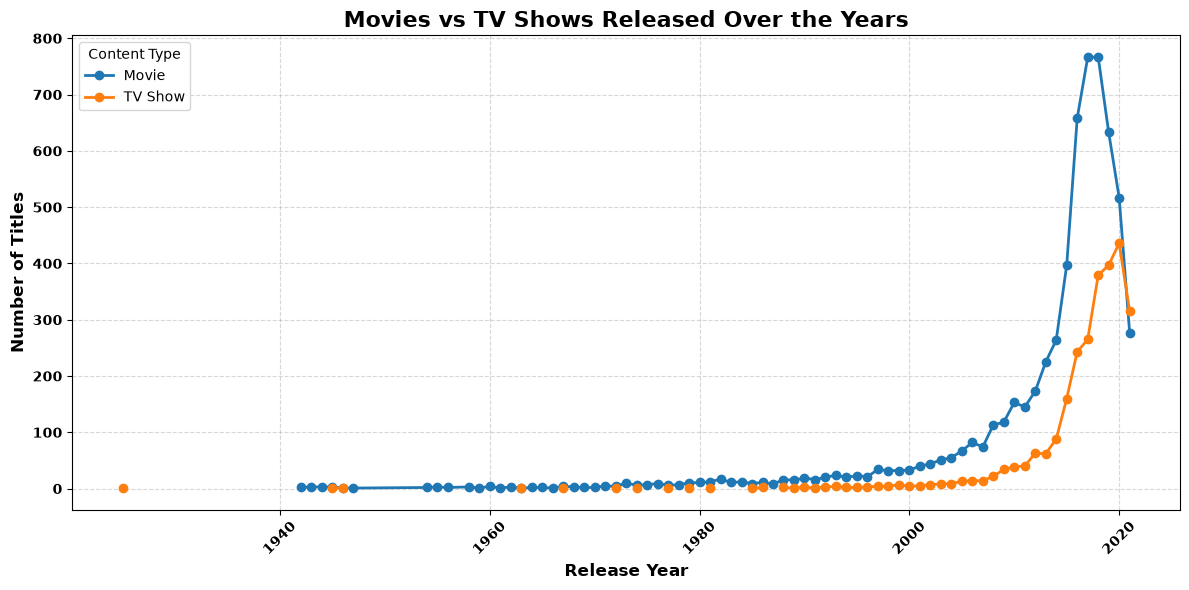

In [18]:
trend = (df.groupby(["release_year", "type"])["show_id"].count().unstack())

plt.figure(figsize=(12,6))

for col in trend.columns:
    plt.plot(trend.index,trend[col],marker="o",linewidth=2,label=col)

plt.title("Movies vs TV Shows Released Over the Years",fontsize=16,fontweight="bold")

plt.xlabel("Release Year",fontsize=12, fontweight="bold")
plt.ylabel("Number of Titles",fontsize=12,fontweight="bold")

plt.xticks(fontweight="bold", rotation=45)
plt.yticks(fontweight="bold")

plt.legend(title="Content Type")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

📊 Analysis: Content Ratings by Type

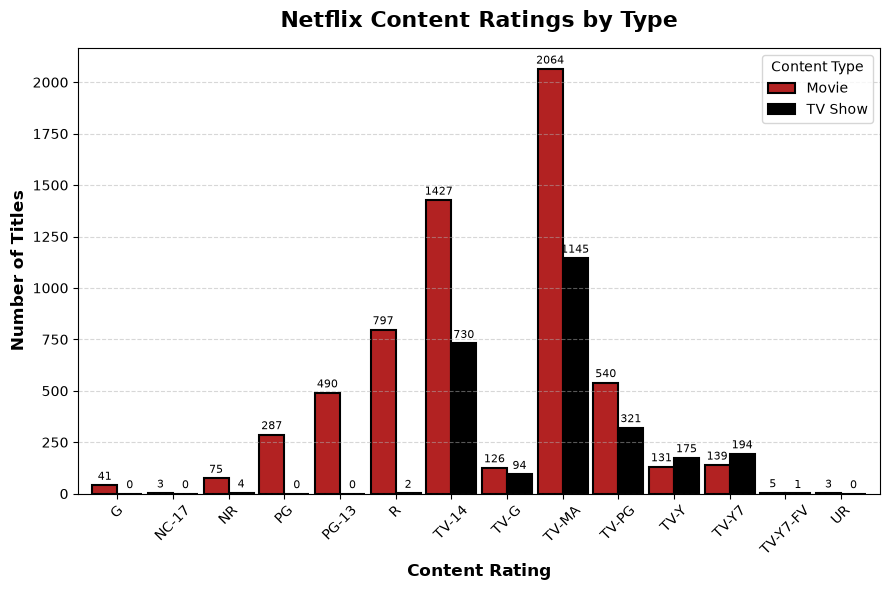

In [19]:
rating_data = df.groupby(["rating", "type"]).size().unstack()

ax = rating_data.plot(kind="bar",figsize=(9,6),color=["firebrick", "black"],edgecolor="black",linewidth=1.5,width=0.9)

plt.title("Netflix Content Ratings by Type",fontsize=16,fontweight="bold",pad=15)

plt.xlabel("Content Rating", fontsize=12, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=12, fontweight="bold")

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Content Type", fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)
plt.tight_layout()
plt.show()

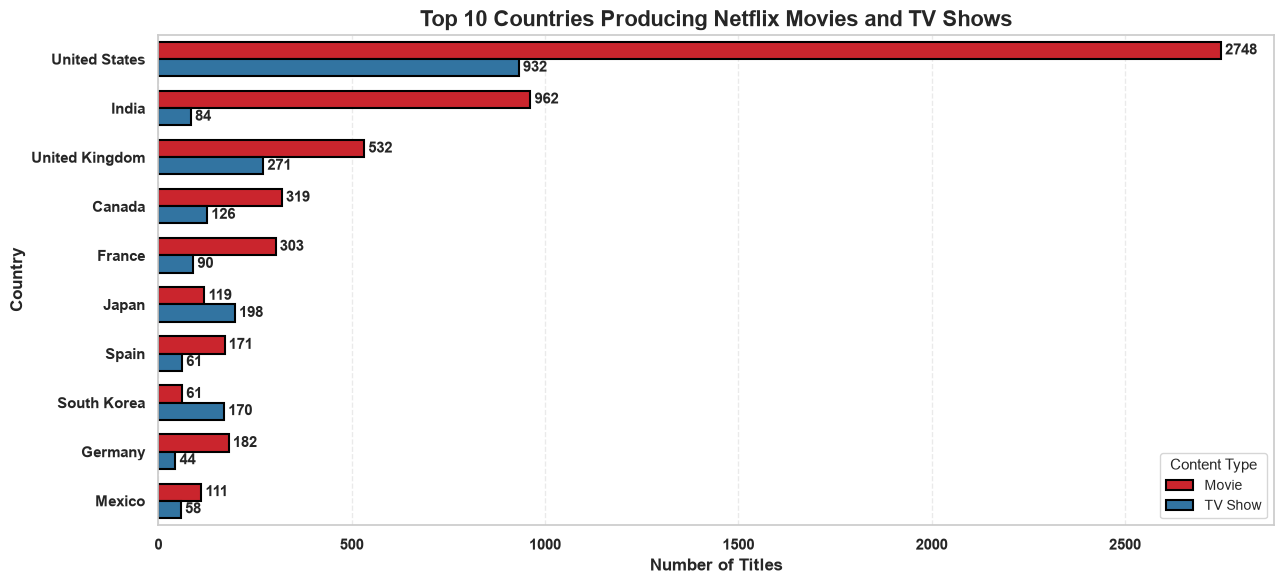

In [42]:
country_df = df.copy()
country_df = country_df.dropna(subset=["country"])

country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")

country_df = country_df[country_df["country"].str.lower() != "unknown"]

top10 = ( country_df["country"].value_counts().head(10) .index)

country_top = country_df[country_df["country"].isin(top10)]

plt.figure(figsize=(13,6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=country_top,y="country",hue="type",order=top10,palette=["#E50914", "#1F77B4"],
                   edgecolor="black",linewidth=1.5,width=0.7)

for container in ax.containers:
    ax.bar_label(container,padding=3,fontsize=11,fontweight="bold")

plt.title("Top 10 Countries Producing Netflix Movies and TV Shows",fontsize=16,fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12,fontweight="bold")
plt.ylabel("Country", fontsize=12,fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.legend(title="Content Type",title_fontsize=11,fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Analysis: Movie Duration by Content Rating

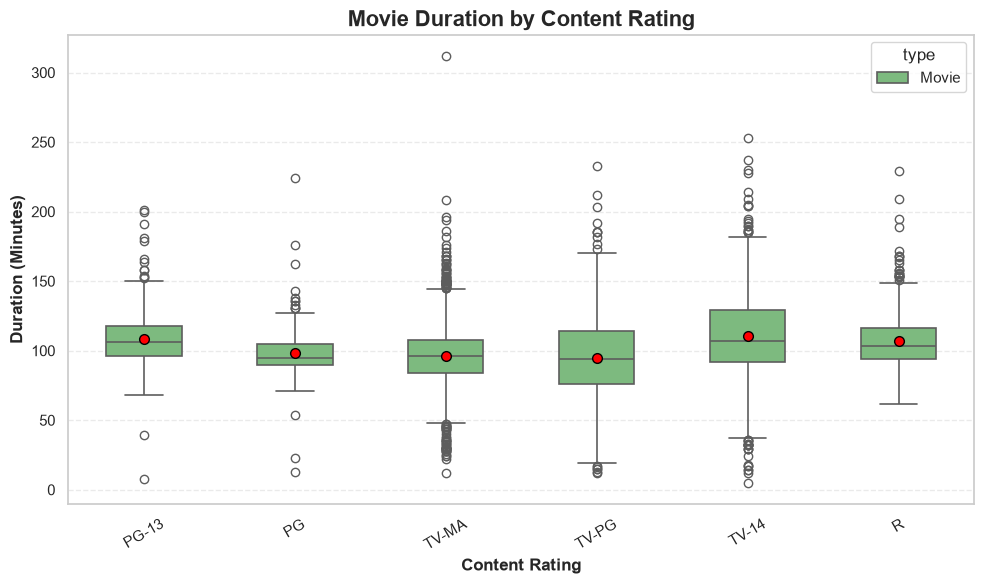

In [22]:
movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = movies["duration"].astype(int)

top_ratings = movies["rating"].value_counts().head(6).index
movies = movies[movies["rating"].isin(top_ratings)]

plt.figure(figsize=(10,6))
sns.boxplot(data=movies, x="rating", y="duration",hue='type', palette="Greens",
            width=0.5,linewidth=1.2,showmeans=True,meanprops={"marker": "o","markerfacecolor": "red","markeredgecolor": "black","markersize": 7}
)

plt.title("Movie Duration by Content Rating", fontsize=16, fontweight="bold")
plt.xlabel("Content Rating", fontsize=12, fontweight="bold")
plt.ylabel("Duration (Minutes)", fontsize=12, fontweight="bold")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


📊 Analysis: Content Ratings by Type

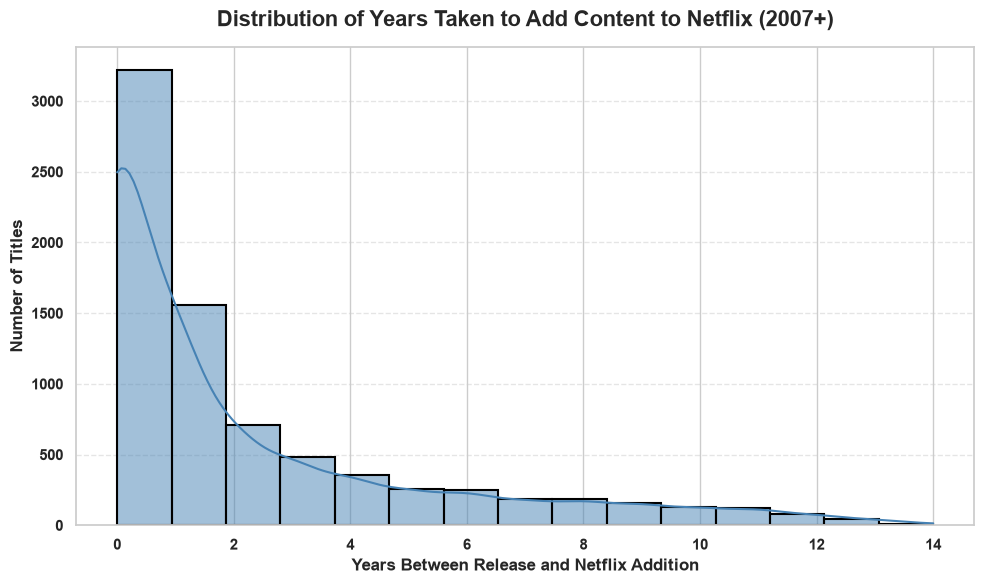

In [23]:
df_filtered = df[df["release_year"] >= 2007].copy()
df_filtered["date_added"] = pd.to_datetime(df_filtered["date_added"],errors="coerce")

df_filtered["years_to_netflix"] = (
    df_filtered["date_added"].dt.year - df_filtered["release_year"])

df_filtered = df_filtered[df_filtered["years_to_netflix"] >= 0]

plt.figure(figsize=(10,6))

sns.histplot(data=df_filtered,x="years_to_netflix",bins=15,kde=True,color="steelblue",edgecolor="black", linewidth=1.5)

plt.title("Distribution of Years Taken to Add Content to Netflix (2007+)",fontsize=16,fontweight="bold", pad=15)
plt.xlabel("Years Between Release and Netflix Addition",fontsize=12,fontweight="bold")
plt.ylabel( "Number of Titles",fontsize=12,fontweight="bold")
plt.xticks(range(0,int(df_filtered["years_to_netflix"].max()) + 2,2),fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

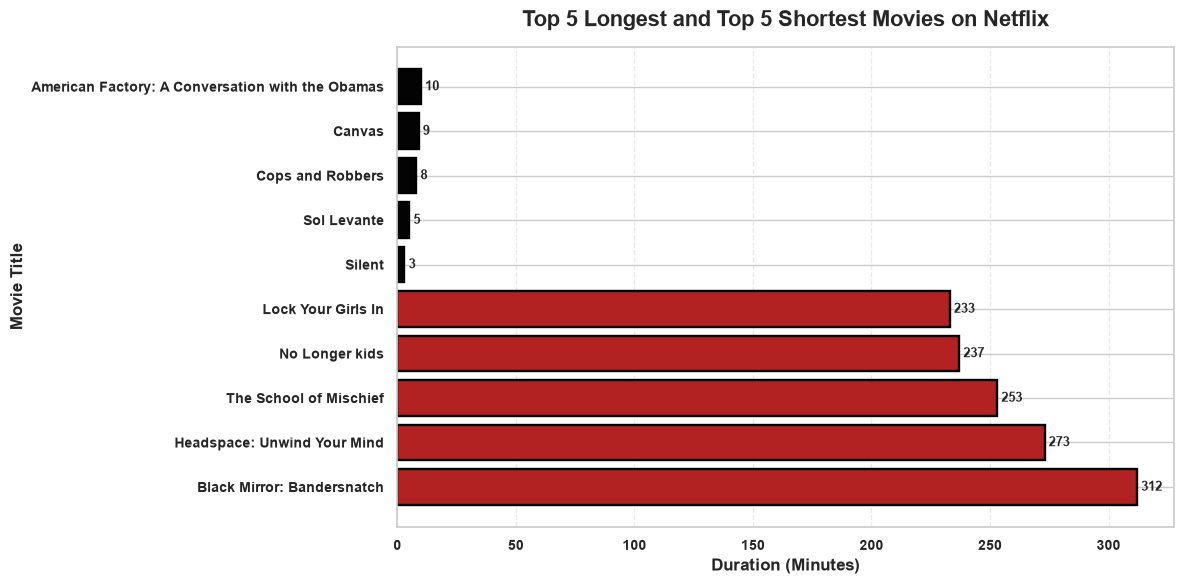

In [24]:
movies = df[df["type"] == "Movie"].copy()
movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = movies["duration"].astype(int)

longest = movies.nlargest(5, "duration")
shortest = movies.nsmallest(5, "duration")
extreme_movies = pd.concat([longest, shortest])

colors = ["firebrick"] * 5 + ["#030303"] * 5

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(extreme_movies["title"], extreme_movies["duration"],color=colors,edgecolor="black",linewidth=1.7)

ax.set_title("Top 5 Longest and Top 5 Shortest Movies on Netflix",fontsize=16,fontweight="bold",pad=15,loc="center")
ax.set_xlabel("Duration (Minutes)",fontsize=12,fontweight="bold")
ax.set_ylabel("Movie Title",fontsize=12,fontweight="bold")
ax.tick_params(axis="both", labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.bar_label(bars,padding=3,fontsize=9,fontweight="bold")
plt.tight_layout()
plt.show()

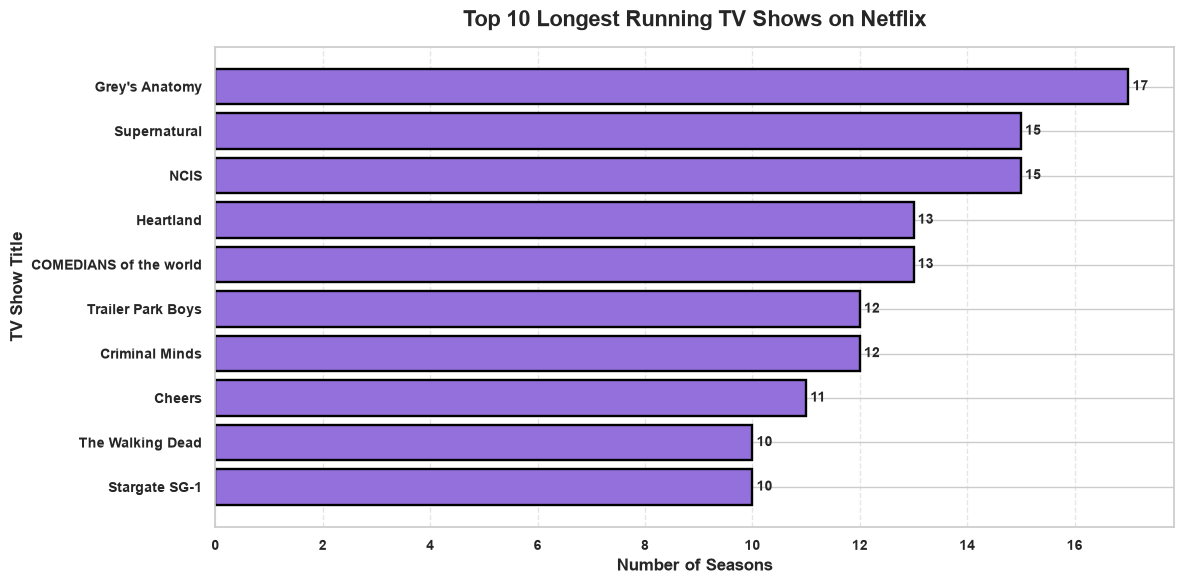

In [26]:
tv = df[df["type"] == "TV Show"].copy()
tv["seasons"] = tv["duration"].str.extract(r"(\d+)").astype(int)
top_tv = tv.nlargest(10, "seasons")
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(top_tv["title"], top_tv["seasons"],color="mediumpurple",edgecolor="black",linewidth=1.7)

ax.set_title("Top 10 Longest Running TV Shows on Netflix",fontsize=16,fontweight="bold",pad=15)
ax.set_xlabel("Number of Seasons",fontsize=12,fontweight="bold")

ax.set_ylabel("TV Show Title",fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(axis="x", linestyle="--", alpha=0.5)

ax.bar_label(bars,padding=3,fontsize=10,fontweight="bold")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

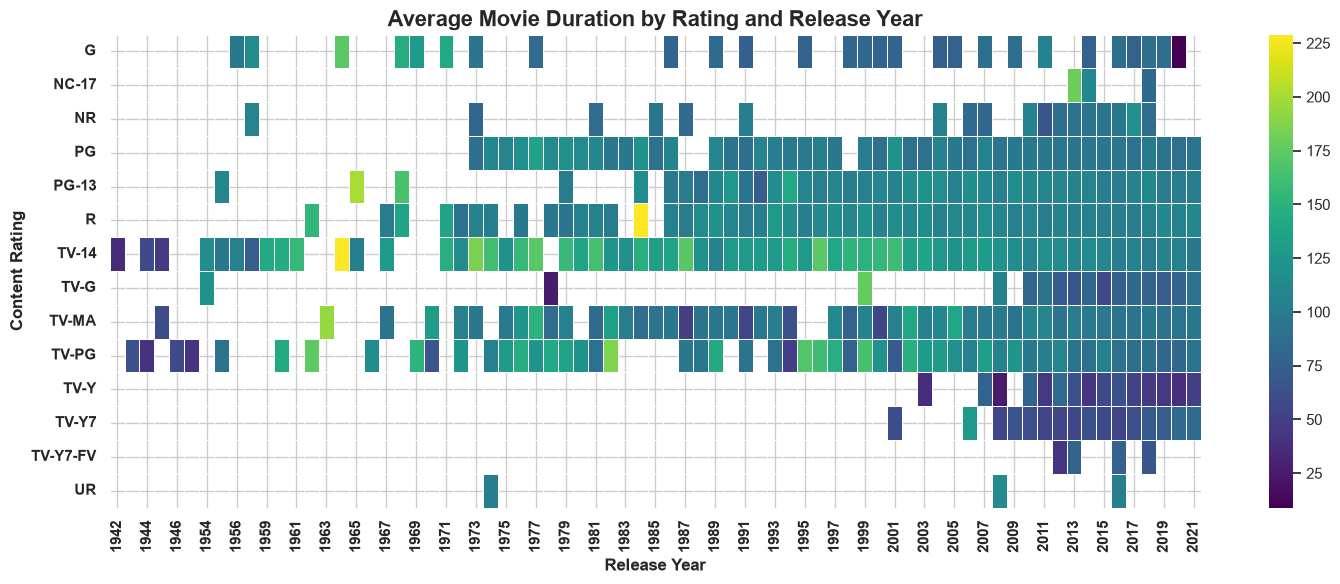

In [27]:
movies = df[df["type"]=="Movie"].copy()
movies["duration"] = movies["duration"].str.replace(" min","",regex=False)
movies["duration"] = movies["duration"].astype(int)

pivot = movies.pivot_table(values="duration",index="rating",columns="release_year",aggfunc="mean")

plt.figure(figsize=(15,6))
sns.heatmap(pivot,cmap="viridis",linewidths=0.4)

plt.title("Average Movie Duration by Rating and Release Year", fontsize=16,fontweight="bold")
plt.xlabel("Release Year",fontsize=12,fontweight="bold")
plt.ylabel("Content Rating", fontsize=12,fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.tight_layout()
plt.show()

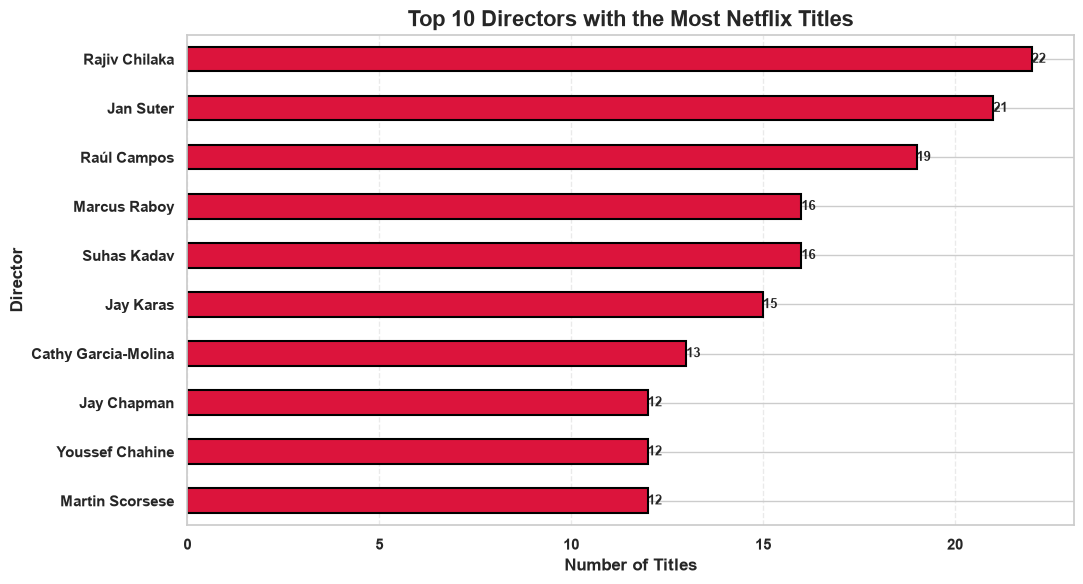

In [28]:
import matplotlib.pyplot as plt

director_df = df.copy()

# Remove rows where director is missing
director_df = director_df.dropna(subset=["director"])

# Split multiple directors into separate rows
director_df["director"] = director_df["director"].str.split(", ")
director_df = director_df.explode("director")

# Remove unwanted values
director_df = director_df[
    (director_df["director"] != "Unknown") &
    (director_df["director"] != "Not Available") &
    (director_df["director"] != "")
]

# Count titles directed
top_directors = (
    director_df.groupby("director")["show_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

ax = top_directors.sort_values().plot(
    kind="barh",
    color="crimson",
    edgecolor="black",
    linewidth=1.5
)

plt.title(
    "Top 10 Directors with the Most Netflix Titles",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Titles",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Director",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

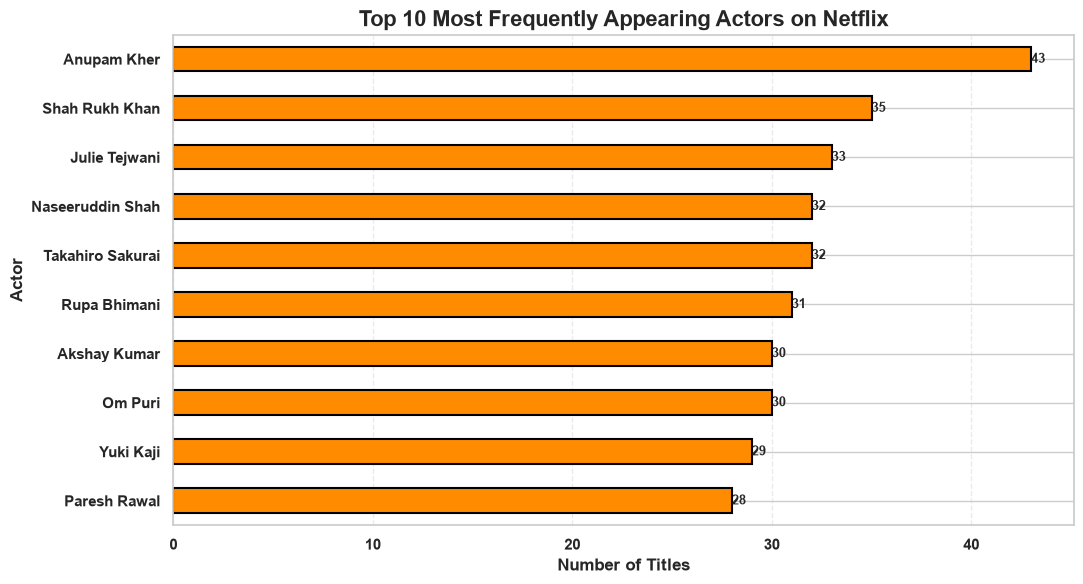

In [30]:
import matplotlib.pyplot as plt

cast_df = df.copy()

# Remove missing values instead of filling them
cast_df = cast_df.dropna(subset=["cast"])

# Split multiple actors into separate rows
cast_df["cast"] = cast_df["cast"].str.split(", ")
cast_df = cast_df.explode("cast")

# Remove unwanted values
cast_df = cast_df[
    (cast_df["cast"] != "Unknown") &
    (cast_df["cast"] != "Not Available") &
    (cast_df["cast"] != "")
]

# Count appearances
top_cast = (
    cast_df.groupby("cast")["show_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

ax = top_cast.sort_values().plot(
    kind="barh",
    color="darkorange",
    edgecolor="black",
    linewidth=1.5
)

plt.title(
    "Top 10 Most Frequently Appearing Actors on Netflix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Number of Titles",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Actor",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

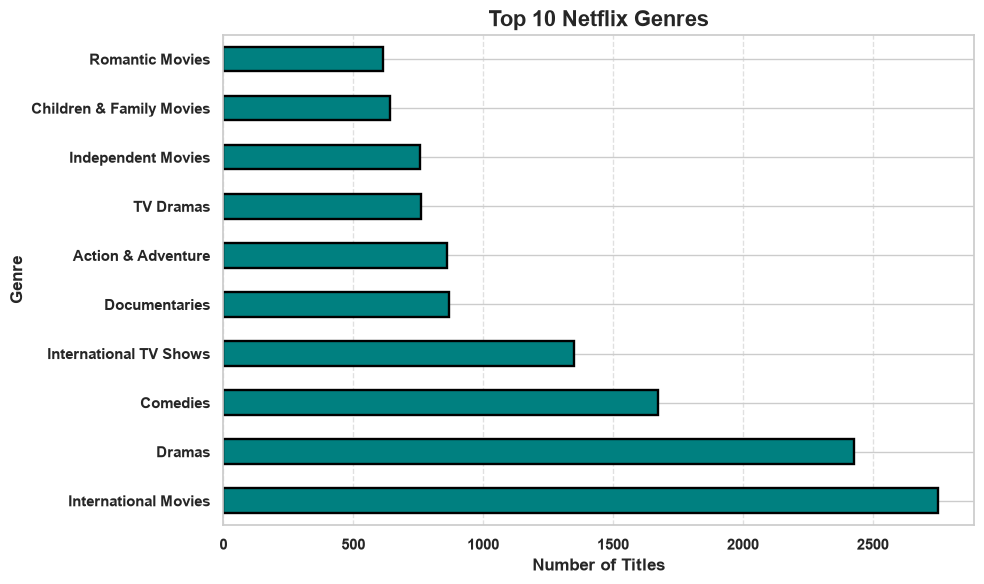

In [32]:
genre_df = df.copy()
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")
genre_df = genre_df.explode("listed_in")

top_genres = (genre_df.groupby("listed_in")["show_id"].count().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))

top_genres.plot(kind="barh",color="teal",edgecolor="black",linewidth=1.7)

plt.title("Top 10 Netflix Genres",fontsize=16,fontweight="bold")

plt.xlabel("Number of Titles",fontsize=12,fontweight="bold")
plt.ylabel("Genre",fontsize=12,fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

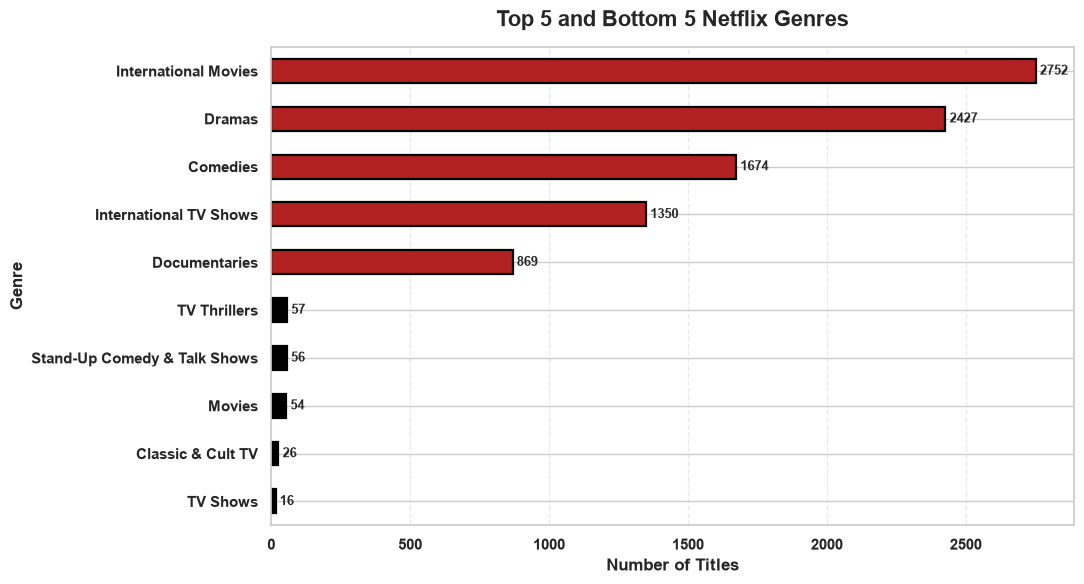

In [33]:
import matplotlib.pyplot as plt
genre_df = df.copy()
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("listed_in")
genre_counts = genre_df.groupby("listed_in")["show_id"].count().sort_values()

bottom5 = genre_counts.head(5)
top5 = genre_counts.tail(5)

combined = pd.concat([bottom5, top5])
colors = ["black"] * 5 + ["firebrick"] * 5
plt.figure(figsize=(11,6))

ax = combined.plot(kind="barh",color=colors,edgecolor="black",linewidth=1.6)

plt.title("Top 5 and Bottom 5 Netflix Genres",fontsize=16,fontweight="bold",pad=15)
plt.xlabel("Number of Titles",fontsize=12,fontweight="bold")
plt.ylabel("Genre",fontsize=12, fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container,fontsize=9,fontweight="bold", padding=3)

plt.tight_layout()
plt.show()